# Lista 3 - RNN, LSTM, GRU e Transformers
**Aluno:** Vitor Fontenele de Oliveira Linhares

**Mátricula:** 1700778

## Imports

In [ ]:
import numpy as np
import pandas as pd
import re
from collections import Counter
import copy

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from datasets import load_dataset
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Questão 1: RNN - AG News

### Exploração e Entendimento Inicial do Dataset

In [54]:
ds = load_dataset("sh0416/ag_news")

print(ds)

df_train_raw = pd.DataFrame(ds["train"])
df_test_raw = pd.DataFrame(ds["test"])

id2label = {1: "World", 2: "Sports", 3: "Business", 4: "Sci/Tech"}

def normalize_label_to_one_based(label_series):
    unique_vals = set(label_series.unique())
    if unique_vals.issubset({1, 2, 3, 4}):
        return label_series.astype(int)
    if unique_vals.issubset({0, 1, 2, 3}):
        return (label_series.astype(int) + 1)
    raise ValueError(f"Labels fora do esperado: {sorted(unique_vals)}")

def build_exploration_df(df_raw):
    needed_cols = {"label", "title", "description"}
    if not needed_cols.issubset(df_raw.columns):
        raise ValueError("Dataset nao possui as colunas esperadas: label, title e description.")

    df = df_raw[["label", "title", "description"]].copy()
    label_id = normalize_label_to_one_based(df["label"])
    df["label"] = label_id.map(id2label)
    df["text"] = (df["title"].astype(str).str.strip() + " " + df["description"].astype(str).str.strip()).str.strip()

    df = df[["label", "text"]].reset_index(drop=True)
    df.insert(0, "id", df.index + 1)
    return df

df_train = build_exploration_df(df_train_raw)
df_test = build_exploration_df(df_test_raw)

print("\nPrimeiras linhas:")
display(df_train[["id", "label", "text"]].head(3))

train_counts = df_train["label"].value_counts().reindex(["World", "Sports", "Business", "Sci/Tech"], fill_value=0)
test_counts = df_test["label"].value_counts().reindex(["World", "Sports", "Business", "Sci/Tech"], fill_value=0)

dist_df = pd.DataFrame({
    "label": train_counts.index,
    "train_count": train_counts.values,
    "test_count": test_counts.values,
})
dist_df["train_pct"] = (dist_df["train_count"] / len(df_train) * 100).round(2)
dist_df["test_pct"] = (dist_df["test_count"] / len(df_test) * 100).round(2)

print("\nDistribuicao por classe:")
display(dist_df)

sample_df = df_train.sample(n=min(20000, len(df_train)), random_state=42).copy()
sample_df["text_n_words"] = sample_df["text"].astype(str).str.split().str.len()

print("\nEstatisticas de tamanho de text:")
display(sample_df[["text_n_words"]].describe().T)

example_parts = []
for label_name in ["World", "Sports", "Business", "Sci/Tech"]:
    class_df = df_train[df_train["label"] == label_name]
    class_sample = class_df.sample(n=min(1, len(class_df)), random_state=42)
    example_parts.append(class_sample)

examples = pd.concat(example_parts, ignore_index=True).sort_values("label").reset_index(drop=True)

print("\nExemplos de noticias por classe:")
display(examples[["id", "label", "text"]])

DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'description'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['label', 'title', 'description'],
        num_rows: 7600
    })
})

Primeiras linhas:


,id,label,text
0,1,Business,Wall St. Bears Claw Back Into the Black (Reute...
1,2,Business,Carlyle Looks Toward Commercial Aerospace (Reu...
2,3,Business,Oil and Economy Cloud Stocks' Outlook (Reuters...



Distribuicao por classe:


,label,train_count,test_count,train_pct,test_pct
0,World,30000,1900,25.0,25.0
1,Sports,30000,1900,25.0,25.0
2,Business,30000,1900,25.0,25.0
3,Sci/Tech,30000,1900,25.0,25.0



Estatisticas de tamanho de text:


,count,mean,std,min,25%,50%,75%,max
text_n_words,20000.0,37.7904,10.140711,9.0,32.0,37.0,43.0,171.0



Exemplos de noticias por classe:


,id,label,text
0,9286,Business,US house sales fall in July Sales of non-new h...
1,9048,Sci/Tech,Gartner optimistic about chip numbers But that...
2,9827,Sports,Second Andre win in a row boosts US gold medal...
3,8898,World,"Explosion Rocks Baghdad Neighborhood BAGHDAD, ..."


###  Parâmetros e Configuração

In [108]:
rnn_static_config = {
    "data": {
        "label2target": {"World": 0, "Sports": 1, "Business": 2, "Sci/Tech": 3},
        "val_size": 0.15,
        "random_state": 42,
        "min_freq": 2,
        "max_vocab_size": 2000,
        "special_tokens": ["<pad>", "<unk>"],
        "max_len_percentile": 95,
        "max_len_min": 16,
        "max_len_cap": 96,
        "batch_size": 256,
    },
    "train": {
        "epochs": 5,
        "learning_rate": 1e-3,
        "weight_decay": 2e-5,
        "grad_clip": 1.0,
        "early_stopping_patience": 2,
        "show_progress": True,
    },
}

rnn_model_configs = [
    {
        "name": "Config A",
        "model": {
            "embedding_dim": 64,
            "hidden_size": 64,
            "num_layers": 1,
            "nonlinearity": "tanh",
            "dropout": 0.0,
            "bidirectional": False,
        },
    },
    {
        "name": "Config B",
        "model": {
            "embedding_dim": 160,
            "hidden_size": 256,
            "num_layers": 2,
            "nonlinearity": "relu",
            "dropout": 0.3,
            "bidirectional": True,
        },
    },
]

print("\nConfiguração fixa:\n")
for section_name in ["data", "train"]:
    print(f"[{section_name}]")
    for k, v in rnn_static_config[section_name].items():
        print(f"- {k}: {v}")
    print()

model_cfg_by_name = {}
for i, cfg_item in enumerate(rnn_model_configs):
    cfg_name = cfg_item.get("name", f"Config {i}")
    model_cfg_by_name[cfg_name] = cfg_item["model"]
model_cfg_df = pd.DataFrame(model_cfg_by_name)
model_cfg_df.index.name = "model_param"

print("Comparação de modelos:")
display(model_cfg_df)


Configuração fixa:

[data]
- label2target: {'World': 0, 'Sports': 1, 'Business': 2, 'Sci/Tech': 3}
- val_size: 0.15
- random_state: 42
- min_freq: 2
- max_vocab_size: 2000
- special_tokens: ['<pad>', '<unk>']
- max_len_percentile: 95
- max_len_min: 16
- max_len_cap: 96
- batch_size: 256

[train]
- epochs: 5
- learning_rate: 0.001
- weight_decay: 2e-05
- grad_clip: 1.0
- early_stopping_patience: 2
- show_progress: True

Comparação de modelos:


,Config A,Config B
model_param,,
embedding_dim,64,160
hidden_size,64,256
num_layers,1,2
nonlinearity,tanh,relu
dropout,0.0,0.3
bidirectional,False,True


### Pré-processamento para RNN 

In [109]:
df_train_model = df_train[["text", "label"]].copy()
df_test_model = df_test[["text", "label"]].copy()

label2target = rnn_static_config["data"]["label2target"]
df_train_model["target"] = df_train_model["label"].map(label2target)
df_test_model["target"] = df_test_model["label"].map(label2target)

if df_train_model["target"].isna().any() or df_test_model["target"].isna().any():
    raise ValueError("Foram encontrados labels fora do mapeamento esperado.")

train_df, val_df = train_test_split(
    df_train_model,
    test_size=rnn_static_config["data"]["val_size"],
    random_state=rnn_static_config["data"]["random_state"],
    stratify=df_train_model["target"]
)

print("Shapes dos splits:")
print(f"train: {train_df.shape} | val: {val_df.shape} | test: {df_test_model.shape}")

def tokenize(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.split()

counter = Counter()
for txt in train_df["text"]:
    counter.update(tokenize(txt))

min_freq = rnn_static_config["data"]["min_freq"]
max_vocab_size = rnn_static_config["data"]["max_vocab_size"]
special_tokens = rnn_static_config["data"]["special_tokens"]

vocab_tokens = [tok for tok, freq in counter.items() if freq >= min_freq]
vocab_tokens = sorted(vocab_tokens, key=lambda t: counter[t], reverse=True)
vocab_tokens = vocab_tokens[:max_vocab_size - len(special_tokens)]

itos = special_tokens + vocab_tokens
stoi = {tok: idx for idx, tok in enumerate(itos)}

PAD_IDX = stoi["<pad>"]
UNK_IDX = stoi["<unk>"]

def encode_text(text):
    return [stoi.get(tok, UNK_IDX) for tok in tokenize(text)]

train_df = train_df.copy()
val_df = val_df.copy()
test_df = df_test_model.copy()

train_df["seq"] = train_df["text"].map(encode_text)
val_df["seq"] = val_df["text"].map(encode_text)
test_df["seq"] = test_df["text"].map(encode_text)

train_lengths = train_df["seq"].map(len).values
max_len = int(np.percentile(train_lengths, rnn_static_config["data"]["max_len_percentile"]))
max_len = max(rnn_static_config["data"]["max_len_min"], min(max_len, rnn_static_config["data"]["max_len_cap"]))

def pad_or_truncate(seq, max_len, pad_idx=PAD_IDX):
    if len(seq) >= max_len:
        return seq[:max_len]
    return seq + [pad_idx] * (max_len - len(seq))

X_train = np.array([pad_or_truncate(s, max_len) for s in train_df["seq"]], dtype=np.int64)
X_val = np.array([pad_or_truncate(s, max_len) for s in val_df["seq"]], dtype=np.int64)
X_test = np.array([pad_or_truncate(s, max_len) for s in test_df["seq"]], dtype=np.int64)

y_train = train_df["target"].to_numpy(dtype=np.int64)
y_val = val_df["target"].to_numpy(dtype=np.int64)
y_test = test_df["target"].to_numpy(dtype=np.int64)

batch_size = rnn_static_config["data"]["batch_size"]
pin_memory = device.type == "cuda"
loader_kwargs = {"batch_size": batch_size, "pin_memory": pin_memory}

train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.long),
    torch.tensor(y_train, dtype=torch.long)
)
val_dataset = TensorDataset(
    torch.tensor(X_val, dtype=torch.long),
    torch.tensor(y_val, dtype=torch.long)
)
test_dataset = TensorDataset(
    torch.tensor(X_test, dtype=torch.long),
    torch.tensor(y_test, dtype=torch.long)
)

train_loader = DataLoader(train_dataset, shuffle=True, **loader_kwargs)
val_loader = DataLoader(val_dataset, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_kwargs)

Shapes dos splits:
train: (102000, 3) | val: (18000, 3) | test: (7600, 3)


### RNN

In [110]:
num_classes = len(rnn_static_config["data"]["label2target"])

class NewsRNNClassifier(nn.Module):
    def __init__(self, vocab_size, pad_idx, cfg):
        super().__init__()
        model_cfg = cfg["model"]

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=model_cfg["embedding_dim"],
            padding_idx=pad_idx,
        )

        effective_dropout = model_cfg["dropout"] if model_cfg["num_layers"] > 1 else 0.0

        self.rnn = nn.RNN(
            input_size=model_cfg["embedding_dim"],
            hidden_size=model_cfg["hidden_size"],
            num_layers=model_cfg["num_layers"],
            nonlinearity=model_cfg["nonlinearity"],
            batch_first=True,
            dropout=effective_dropout,
            bidirectional=model_cfg["bidirectional"],
        )

        out_dim = model_cfg["hidden_size"] * (2 if model_cfg["bidirectional"] else 1)
        self.fc = nn.Linear(out_dim, num_classes)

    def forward(self, x):
        emb = self.embedding(x)
        _, h_n = self.rnn(emb)

        if self.rnn.bidirectional:
            h_last = torch.cat((h_n[-2], h_n[-1]), dim=1)
        else:
            h_last = h_n[-1]

        logits = self.fc(h_last)
        return logits


def run_epoch(
    model,
    loader,
    criterion,
    optimizer=None,
    grad_clip=None,
    max_batches=None,
    progress_bar=None,
):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_examples = 0
    all_preds = []
    all_targets = []

    for batch_idx, (xb, yb) in enumerate(loader):
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        if is_train:
            loss.backward()
            if grad_clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

        batch_size = yb.size(0)
        total_loss += loss.item() * batch_size
        total_examples += batch_size
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(yb.detach().cpu().numpy())

        if progress_bar is not None and is_train:
            progress_bar.update(1)

        if max_batches is not None and (batch_idx + 1) >= max_batches:
            break

    avg_loss = total_loss / max(total_examples, 1)
    acc = accuracy_score(all_targets, all_preds)
    prec = precision_score(all_targets, all_preds, average="macro", zero_division=0)
    rec = recall_score(all_targets, all_preds, average="macro", zero_division=0)
    f1 = f1_score(all_targets, all_preds, average="macro", zero_division=0)

    return {
        "loss": avg_loss,
        "acc": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
    }


def build_cfg_from_rnn_config(base_cfg, config_item):
    if "model" not in config_item:
        raise ValueError("Cada item de rnn_configs precisa ter a chave 'model'.")

    return {
        "name": config_item.get("name", "Config"),
        "data": copy.deepcopy(base_cfg["data"]),
        "train": copy.deepcopy(base_cfg["train"]),
        "model": copy.deepcopy(config_item["model"]),
    }


def train_rnn_experiment(cfg, verbose=False):
    model = NewsRNNClassifier(vocab_size=len(itos), pad_idx=PAD_IDX, cfg=cfg).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        model.parameters(),
        lr=cfg["train"]["learning_rate"],
        weight_decay=cfg["train"]["weight_decay"],
    )

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": [],
        "train_f1": [], "val_f1": [],
    }

    max_train_batches = cfg["train"].get("max_train_batches")
    max_eval_batches = cfg["train"].get("max_eval_batches")
    show_progress = cfg["train"].get("show_progress", False)

    best_val_loss = float("inf")
    best_state = None
    patience = 0

    total_epochs = cfg["train"]["epochs"]
    cfg_name = cfg.get("name", "Config")

    progress_bar = None
    if show_progress:
        train_steps_total = len(train_loader)
        if max_train_batches is not None:
            train_steps_total = min(train_steps_total, int(max_train_batches))
        total_steps = max(1, total_epochs * train_steps_total)
        progress_bar = tqdm(
            total=total_steps,
            desc=f"{cfg_name}",
            leave=True,
            dynamic_ncols=True,
            unit="batch",
        )

    for epoch in range(1, total_epochs + 1):

        train_metrics = run_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            grad_clip=cfg["train"]["grad_clip"],
            max_batches=max_train_batches,
            progress_bar=progress_bar,
        )
        val_metrics = run_epoch(
            model,
            val_loader,
            criterion,
            optimizer=None,
            max_batches=max_eval_batches,
            progress_bar=None,
        )

        history["train_loss"].append(train_metrics["loss"])
        history["val_loss"].append(val_metrics["loss"])
        history["train_acc"].append(train_metrics["acc"])
        history["val_acc"].append(val_metrics["acc"])
        history["train_f1"].append(train_metrics["f1"])
        history["val_f1"].append(val_metrics["f1"])

        if verbose:
            print(
                f"Epoch {epoch:02d}/{cfg['train']['epochs']} | "
                f"train_loss={train_metrics['loss']:.4f} val_loss={val_metrics['loss']:.4f} | "
                f"train_acc={train_metrics['acc']:.4f} val_acc={val_metrics['acc']:.4f} | "
                f"val_f1={val_metrics['f1']:.4f}"
            )

        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience = 0
        else:
            patience += 1
            if patience >= cfg["train"]["early_stopping_patience"]:
                if verbose:
                    print("Early stopping acionado.")
                break

    if progress_bar is not None:
        progress_bar.close()

    if best_state is not None:
        model.load_state_dict(best_state)

    test_metrics = run_epoch(
        model,
        test_loader,
        criterion,
        optimizer=None,
        max_batches=max_eval_batches,
        progress_bar=None,
    )

    all_preds = []
    all_targets = []
    model.eval()
    with torch.no_grad():
        for batch_idx, (xb, yb) in enumerate(test_loader):
            xb = xb.to(device, non_blocking=True)
            logits = model(xb)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(yb.numpy())

            if max_eval_batches is not None and (batch_idx + 1) >= max_eval_batches:
                break

    cm = confusion_matrix(all_targets, all_preds)
    label_order = ["World", "Sports", "Business", "Sci/Tech"]
    cm_df = pd.DataFrame(cm, index=[f"Real {x}" for x in label_order], columns=[f"Pred {x}" for x in label_order])

    return {
        "model": model,
        "history": history,
        "test_metrics": test_metrics,
        "confusion_matrix": cm,
        "confusion_matrix_df": cm_df,
        "label_order": label_order,
        "used_cfg": cfg,
    }

### Rodando os Experimentos

In [111]:
experiment_runs = {}
for i, cfg_item in enumerate(rnn_model_configs):
    cfg_name = cfg_item.get("name", f"Config {i}")
    exp_cfg = build_cfg_from_rnn_config(rnn_static_config, cfg_item)
    experiment_runs[cfg_name] = train_rnn_experiment(cfg=exp_cfg, verbose=False)

Config B: 100%|██████████| 1995/1995 [04:37<00:00,  7.19batch/s]


### Resultados

Metricas:


config,loss,accuracy,precision_macro,recall_macro,f1_macro
Config A,1.162872,0.438289,0.448196,0.438289,0.321661
Config B,0.338871,0.882763,0.885462,0.882763,0.882594


Matrizes de confusão (uma por config):

Config A


,Pred World,Pred Sports,Pred Business,Pred Sci/Tech
Real World,15,462,31,1392
Real Sports,4,1590,5,301
Real Business,9,160,48,1683
Real Sci/Tech,12,180,30,1678



Config B


,Pred World,Pred Sports,Pred Business,Pred Sci/Tech
Real World,1619,64,102,115
Real Sports,31,1828,14,27
Real Business,57,34,1539,270
Real Sci/Tech,43,38,96,1723


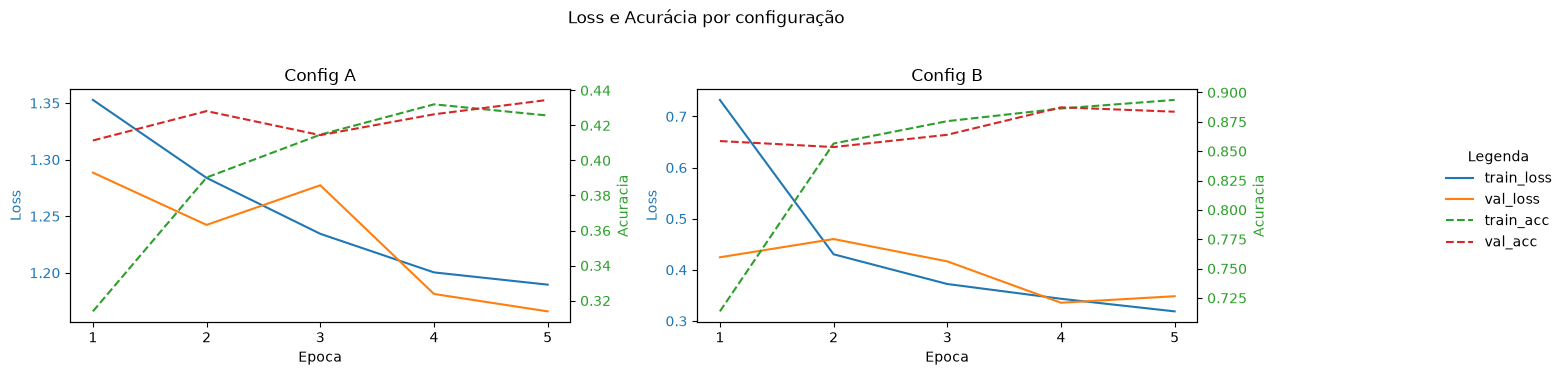

In [112]:
rows = []
for cfg_name, run in experiment_runs.items():
    tm = run["test_metrics"]
    rows.append({
        "config": cfg_name,
        "loss": tm["loss"],
        "accuracy": tm["acc"],
        "precision_macro": tm["precision"],
        "recall_macro": tm["recall"],
        "f1_macro": tm["f1"],
    })
metrics_df = pd.DataFrame(rows)

print("Metricas:")
display(metrics_df.style.hide(axis="index"))

print("Matrizes de confusão (uma por config):")
for cfg_name, run in experiment_runs.items():
    print(f"\n{cfg_name}")
    display(run["confusion_matrix_df"])

cfg_names = list(experiment_runs.keys())
n_cfg = len(cfg_names)
fig, axes = plt.subplots(1, n_cfg, figsize=(7.2 * n_cfg, 3.6), squeeze=False)
axes = axes[0]

legend_handles = None
legend_labels = None

for i, cfg_name in enumerate(cfg_names):
    run = experiment_runs[cfg_name]
    history = run["history"]
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    ax1 = axes[i]
    ln1 = ax1.plot(epochs, history["train_loss"], label="train_loss", color="tab:blue")
    ln2 = ax1.plot(epochs, history["val_loss"], label="val_loss", color="tab:orange")
    ax1.set_xlabel("Epoca")
    ax1.set_ylabel("Loss", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")
    ax1.set_xticks(epochs)

    ax2 = ax1.twinx()
    ln3 = ax2.plot(epochs, history["train_acc"], label="train_acc", color="tab:green", linestyle="--")
    ln4 = ax2.plot(epochs, history["val_acc"], label="val_acc", color="tab:red", linestyle="--")
    ax2.set_ylabel("Acuracia", color="tab:green")
    ax2.tick_params(axis="y", labelcolor="tab:green")

    if legend_handles is None:
        legend_handles = ln1 + ln2 + ln3 + ln4
        legend_labels = [l.get_label() for l in legend_handles]

    ax1.set_title(cfg_name)

fig.suptitle("Loss e Acurácia por configuração", y=1.03)
fig.legend(
    legend_handles,
    legend_labels,
    loc="center left",
    bbox_to_anchor=(1.005, 0.5),
    frameon=False,
    title="Legenda",
)

plt.tight_layout(rect=(0, 0, 0.9, 1))
plt.show()

### Discussão & Análise

Este problema trata da classificação do tema de uma notícia (World, Sports, Business, Sci/Tech), portanto é uma tarefa de classificação multiclasse supervisionada. Diferente da classificação binária, aqui trabalhamos com 4 classes e a decisão final é feita entre múltiplos rótulos, o que influencia a escolha das funções de perda e métricas. Como o dado é texto, tratamos a entrada como sequência, visto que a ordem dos tokens importa para interpretação de contexto e para a decisão da classe predita. Além disso, é necessário converter o texto em uma representação numérica (embedding) para que a RNN possa processar, já que ela opera sobre vetores e não sobre texto, o que tem relação com o fato de computadores processarem números e não palavras. O embedding é uma forma de mapear palavras para um espaço vetorial, onde palavras com significados semelhantes ficam próximas.

Primeiro foi feita uma exploração inicial do dataset para entender estrutura, distribuição das classes e formato dos campos. Em seguida, o texto foi preparado para a RNN com normalização, tokenização, construção de vocabulário, mapeamento para índices, truncamento/padding e criação dos DataLoaders. Em poucas palavras: o embedding projeta tokens para um espaço vetorial, e o padding permite batch com tamanhos uniformes.

Uma limitação das RNNs é a dificuldade de capturar dependências muito longas (gradientes tendem a se degradar ao longo do tempo). Esse tipo de limitação motivou arquiteturas como LSTM e GRU. Ainda assim, para texto sequencial, RNN é mais adequada que MLP: na MLP cada entrada é tratada sem memória temporal explícita, enquanto a RNN carrega estado entre passos da sequência.

Para comparação justa de arquitetura, mantive as configurações de dados e treino fixas (`rnn_static_config`) e alterei apenas os parâmetros do modelo (`rnn_model_configs`) entre `Config A` e `Config B`.

1. Quais classes foram mais acertadas?
- Na `Config A`, as classes com melhor acerto foram Sports e Sci/Tech.
- Na `Config B`, Sports e Sci/Tech continuam fortes, e World e Business melhoram bastante em relação à `Config A`.

2. Quais classes foram mais confundidas?
- Na `Config A`, os maiores erros foram World e Business -> Sci/Tech.
- Na `Config B`, a confusão mais recorrente ainda envolve World e Business -> Sci/Tech, porém em escala bem menor.

3. Possíveis causas dos erros
- Ambiguidade semântica entre temas de World, Business e Sci/Tech em parte das notícias.
- Limitações do vocabulário (`max_vocab_size=2000`) e do corte de sequência (`max_len_cap=96`), que podem descartar termos informativos.
- Baixa capacidade da `Config A` para separar fronteiras mais difíceis entre classes.

4. Sinais de underfitting e overfitting
- `Config A`: há sinal claro de underfitting (baixa acurácia geral, macro-F1 baixo e viés claro para prever Sci/Tech, exceto em Sports).
- `Config B`: não há sinal forte de overfitting neste resultado; treino e validação ficam próximos e a generalização no teste é boa, Sci/Tech e Sports continuam com os melhores resultados. Uma acurácia de aproximadamente `88,3%` indica um resultado aceitável e que o modelo é, de fato, utilizável para o problema em questão. 

Em resumo, aumentar a complexidade da rede melhorou de forma relevante a qualidade das previsões sem degradar a generalização observada. As flutuações entre épocas existem, mas não indicam que apenas aumentar épocas resolveria o problema; neste experimento, a escolha de arquitetura teve impacto maior que simplesmente treinar por mais tempo.

## Questão 2: LSTM - IMDb Movie Reviews

### Exploração e Entendimento Inicial do Dataset

In [ ]:
try:
    ds = load_dataset("ajaykarthick/imdb-movie-reviews")
except Exception as e:
    raise RuntimeError(f"Erro ao carregar o dataset 'ajaykarthick/imdb-movie-reviews': {e}")

print(ds)

df_train = pd.DataFrame(ds["train"])
df_test = pd.DataFrame(ds["test"])

print("\nOverview geral:")
print("- colunas:", list(df_train.columns))
print(f"- tamanho train: {df_train.shape} | tamanho test: {df_test.shape}")

if "label" not in df_train.columns or "label" not in df_test.columns:
    raise ValueError("Dataset nao possui a coluna 'label' em train/test.")

def detect_text_column(df_raw):
    text_candidates = ["text", "review", "sentence", "content"]
    for col in text_candidates:
        if col in df_raw.columns:
            return col

    object_cols = [c for c in df_raw.columns if df_raw[c].dtype == "object"]
    if object_cols:
        return object_cols[0]

    raise ValueError("Nao foi possivel identificar uma coluna de texto no dataset.")

text_col = detect_text_column(df_train)
if text_col not in df_test.columns:
    raise ValueError(f"Coluna de texto '{text_col}' nao encontrada no split de teste.")

df_train = df_train[["label", text_col]].rename(columns={text_col: "text"}).reset_index(drop=True)
df_test = df_test[["label", text_col]].rename(columns={text_col: "text"}).reset_index(drop=True)

print("\nValores distintos de label:", sorted(pd.concat([df_train["label"], df_test["label"]]).dropna().unique().tolist()))

expected_labels = {0, 1}
train_label_set = set(df_train["label"].dropna().unique())
test_label_set = set(df_test["label"].dropna().unique())
if not train_label_set.issubset(expected_labels) or not test_label_set.issubset(expected_labels):
    raise ValueError(
        f"Labels inesperados encontrados. train={sorted(train_label_set)} | test={sorted(test_label_set)}"
    )

def validate_no_empty(df, split_name):
    null_label = int(df["label"].isna().sum())
    null_text = int(df["text"].isna().sum())
    empty_text = int(df["text"].astype(str).str.strip().eq("").sum())

    print(f"{split_name}: null_label={null_label}, null_text={null_text}, empty_text={empty_text}")

    if (null_label > 0) or (null_text > 0) or (empty_text > 0):
        raise ValueError(f"Foram encontrados valores vazios em {split_name}.")

print("\nChecagem de valores vazios:")
validate_no_empty(df_train, "train")
validate_no_empty(df_test, "test")

print("\nPrimeiras linhas:")
display(df_train[["label", "text"]].head(3))

train_counts = df_train["label"].value_counts().reindex([0, 1], fill_value=0)
test_counts = df_test["label"].value_counts().reindex([0, 1], fill_value=0)

dist_df = pd.DataFrame({
    "label": train_counts.index,
    "train_count": train_counts.values,
    "test_count": test_counts.values,
})
dist_df["train_pct"] = (dist_df["train_count"] / len(df_train) * 100).round(2)
dist_df["test_pct"] = (dist_df["test_count"] / len(df_test) * 100).round(2)

print("\nDistribuicao por classe (0/1):")
display(dist_df.style.hide(axis="index"))

sample_df = df_train.sample(n=min(20000, len(df_train)), random_state=42).copy()
sample_df["text_n_words"] = sample_df["text"].astype(str).str.split().str.len()

print("\nEstatisticas de tamanho de texto:")
display(sample_df[["text_n_words"]].describe().T)

DatasetDict({
    train: Dataset({
        features: ['review', 'label'],
        num_rows: 40000
    })
    test: Dataset({
        features: ['review', 'label'],
        num_rows: 10000
    })
})

Overview geral:
- colunas: ['review', 'label']
- tamanho train: (40000, 2) | tamanho test: (10000, 2)

Valores distintos de label: [0, 1]

Checagem de valores vazios:
train: null_label=0, null_text=0, empty_text=0
test: null_label=0, null_text=0, empty_text=0

Primeiras linhas (train):


,label,text
0,0,"Ms Aparna Sen, the maker of Mr & Mrs Iyer, dir..."
1,0,"I have seen this film only once, on TV, and it..."
2,1,I was only fourteen when I first saw the Alien...



Distribuicao por classe (0/1):


label,train_count,test_count,train_pct,test_pct
0,20000,5000,50.000000,50.000000
1,20000,5000,50.000000,50.000000



Estatisticas de tamanho de texto:


,count,mean,std,min,25%,50%,75%,max
text_n_words,20000.0,231.63935,170.396298,8.0,126.0,173.0,284.0,2278.0


### Parâmetros e Configuração

In [38]:
lstm_static_config = {
    "data": {
        "label_col": "label",
        "text_col": "text",
        "val_size": 0.15,
        "random_state": 42,
        "clean_text": True,
        "min_freq": 2,
        "max_vocab_size": 30000,
        "special_tokens": ["<pad>", "<unk>"],
        "max_len_percentile": 95,
        "max_len_min": 32,
        "max_len_cap": 300,
        "batch_size": 128,
    },
    "train": {
        "epochs": 5,
        "learning_rate": 1e-3,
        "weight_decay": 1e-5,
        "grad_clip": 1.0,
        "early_stopping_patience": 2,
    },
}

lstm_model_configs = [
    {
        "name": "Config A",
        "model": {
            "embedding_dim": 64,
            "hidden_size": 64,
            "num_layers": 1,
            "dropout": 0.0,
            "bidirectional": False,
        },
    },
    {
        "name": "Config B",
        "model": {
            "embedding_dim": 200,
            "hidden_size": 256,
            "num_layers": 2,
            "dropout": 0.3,
            "bidirectional": True,
        },
    },
]

print("\nConfiguração fixa (LSTM):\n")
for section_name in ["data", "train"]:
    print(f"[{section_name}]")
    for k, v in lstm_static_config[section_name].items():
        print(f"- {k}: {v}")
    print()

model_cfg_by_name = {}
for i, cfg_item in enumerate(lstm_model_configs):
    cfg_name = cfg_item.get("name", f"Config {i}")
    model_cfg_by_name[cfg_name] = cfg_item["model"]
model_cfg_df = pd.DataFrame(model_cfg_by_name)
model_cfg_df.index.name = "model_param"

print("Comparação de modelos (LSTM):")
display(model_cfg_df)


Configuração fixa (LSTM):

[data]
- label_col: label
- text_col: text
- val_size: 0.15
- random_state: 42
- clean_text: True
- min_freq: 2
- max_vocab_size: 30000
- special_tokens: ['<pad>', '<unk>']
- max_len_percentile: 95
- max_len_min: 32
- max_len_cap: 300
- batch_size: 128

[train]
- epochs: 5
- learning_rate: 0.001
- weight_decay: 1e-05
- grad_clip: 1.0
- early_stopping_patience: 2

Comparação de modelos (LSTM):


,Config A,Config B
model_param,,
embedding_dim,64,200
hidden_size,64,256
num_layers,1,2
dropout,0.0,0.3
bidirectional,False,True


### Pré-processamento para LSTM

In [39]:
if "df_train" not in globals() or "df_test" not in globals():
    raise ValueError("Execute a célula de exploração da Questão 2 antes do pré-processamento.")

cfg_data = lstm_static_config["data"]
label_col = cfg_data["label_col"]
text_col = cfg_data["text_col"]

for split_name, df_split in [("train", df_train), ("test", df_test)]:
    missing_cols = {label_col, text_col} - set(df_split.columns)
    if missing_cols:
        raise ValueError(f"Colunas ausentes em {split_name}: {sorted(missing_cols)}")

df_train_model = df_train.copy()
df_test_model = df_test.copy()

for split_name, df_split in [("train", df_train_model), ("test", df_test_model)]:
    null_label = int(df_split[label_col].isna().sum())
    null_text = int(df_split[text_col].isna().sum())
    empty_text = int(df_split[text_col].astype(str).str.strip().eq("").sum())
    if (null_label > 0) or (null_text > 0) or (empty_text > 0):
        raise ValueError(f"Valores vazios encontrados em {split_name}.")

if set(df_train_model[label_col].dropna().unique()) - {0, 1}:
    raise ValueError("Foram encontrados labels fora de 0/1 em train.")
if set(df_test_model[label_col].dropna().unique()) - {0, 1}:
    raise ValueError("Foram encontrados labels fora de 0/1 em test.")

train_df, val_df = train_test_split(
    df_train_model,
    test_size=cfg_data["val_size"],
    random_state=cfg_data["random_state"],
    stratify=df_train_model[label_col],
)

def tokenize(text):
    text = str(text).lower()
    if cfg_data.get("clean_text", True):
        text = re.sub(r"<br\s*/?>", " ", text)
        text = re.sub(r"[^a-z0-9\s]", " ", text)
        text = re.sub(r"\s+", " ", text).strip()
    return text.split()

counter = Counter()
for txt in train_df[text_col]:
    counter.update(tokenize(txt))

min_freq = cfg_data["min_freq"]
max_vocab_size = cfg_data["max_vocab_size"]
special_tokens = cfg_data["special_tokens"]

vocab_tokens = [tok for tok, freq in counter.items() if freq >= min_freq]
vocab_tokens = sorted(vocab_tokens, key=lambda t: counter[t], reverse=True)
vocab_tokens = vocab_tokens[:max_vocab_size - len(special_tokens)]

lstm_itos = special_tokens + vocab_tokens
lstm_stoi = {tok: idx for idx, tok in enumerate(lstm_itos)}

LSTM_PAD_IDX = lstm_stoi["<pad>"]
LSTM_UNK_IDX = lstm_stoi["<unk>"]

def encode_text(text):
    return [lstm_stoi.get(tok, LSTM_UNK_IDX) for tok in tokenize(text)]

train_df = train_df.copy()
val_df = val_df.copy()
test_df = df_test_model.copy()

train_df["seq"] = train_df[text_col].map(encode_text)
val_df["seq"] = val_df[text_col].map(encode_text)
test_df["seq"] = test_df[text_col].map(encode_text)

train_lengths = train_df["seq"].map(len).values
lstm_max_len = int(np.percentile(train_lengths, cfg_data["max_len_percentile"]))
lstm_max_len = max(cfg_data["max_len_min"], min(lstm_max_len, cfg_data["max_len_cap"]))

def pad_or_truncate(seq, max_len, pad_idx=LSTM_PAD_IDX):
    if len(seq) >= max_len:
        return seq[:max_len]
    return seq + [pad_idx] * (max_len - len(seq))

X_train = np.array([pad_or_truncate(s, lstm_max_len) for s in train_df["seq"]], dtype=np.int64)
X_val = np.array([pad_or_truncate(s, lstm_max_len) for s in val_df["seq"]], dtype=np.int64)
X_test = np.array([pad_or_truncate(s, lstm_max_len) for s in test_df["seq"]], dtype=np.int64)

y_train = train_df[label_col].to_numpy(dtype=np.int64)
y_val = val_df[label_col].to_numpy(dtype=np.int64)
y_test = test_df[label_col].to_numpy(dtype=np.int64)

batch_size = cfg_data["batch_size"]
pin_memory = device.type == "cuda"
loader_kwargs = {"batch_size": batch_size, "pin_memory": pin_memory}

lstm_train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.long),
    torch.tensor(y_train, dtype=torch.long),
)
lstm_val_dataset = TensorDataset(
    torch.tensor(X_val, dtype=torch.long),
    torch.tensor(y_val, dtype=torch.long),
)
lstm_test_dataset = TensorDataset(
    torch.tensor(X_test, dtype=torch.long),
    torch.tensor(y_test, dtype=torch.long),
)

lstm_train_loader = DataLoader(lstm_train_dataset, shuffle=True, **loader_kwargs)
lstm_val_loader = DataLoader(lstm_val_dataset, shuffle=False, **loader_kwargs)
lstm_test_loader = DataLoader(lstm_test_dataset, shuffle=False, **loader_kwargs)

print("Pré-processamento LSTM concluído.")
print(f"splits -> train: {len(y_train)}, val: {len(y_val)}, test: {len(y_test)}")
print(f"vocab_size: {len(lstm_itos)} | max_len: {lstm_max_len} | batch_size: {batch_size}")

Pré-processamento LSTM concluído.
splits -> train: 34000, val: 6000, test: 10000
vocab_size: 30000 | max_len: 300 | batch_size: 128


### LSTM

In [40]:
num_classes = len(np.unique(np.concatenate([y_train, y_val, y_test])))

class SentimentLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, pad_idx, cfg):
        super().__init__()
        model_cfg = cfg["model"]

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=model_cfg["embedding_dim"],
            padding_idx=pad_idx,
        )

        effective_dropout = model_cfg["dropout"] if model_cfg["num_layers"] > 1 else 0.0

        self.lstm = nn.LSTM(
            input_size=model_cfg["embedding_dim"],
            hidden_size=model_cfg["hidden_size"],
            num_layers=model_cfg["num_layers"],
            batch_first=True,
            dropout=effective_dropout,
            bidirectional=model_cfg["bidirectional"],
        )

        out_dim = model_cfg["hidden_size"] * (2 if model_cfg["bidirectional"] else 1)
        self.fc = nn.Linear(out_dim, num_classes)

    def forward(self, x):
        emb = self.embedding(x)
        _, (h_n, _) = self.lstm(emb)

        if self.lstm.bidirectional:
            h_last = torch.cat((h_n[-2], h_n[-1]), dim=1)
        else:
            h_last = h_n[-1]

        logits = self.fc(h_last)
        return logits

def run_lstm_epoch(
    model,
    loader,
    criterion,
    optimizer=None,
    grad_clip=None,
    max_batches=None,
):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_examples = 0
    all_preds = []
    all_targets = []

    for batch_idx, (xb, yb) in enumerate(loader):
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        if is_train:
            loss.backward()
            if grad_clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

        batch_size = yb.size(0)
        total_loss += loss.item() * batch_size
        total_examples += batch_size

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(yb.detach().cpu().numpy())

        if max_batches is not None and (batch_idx + 1) >= max_batches:
            break

    avg_loss = total_loss / max(total_examples, 1)
    acc = accuracy_score(all_targets, all_preds)
    prec = precision_score(all_targets, all_preds, zero_division=0)
    rec = recall_score(all_targets, all_preds, zero_division=0)
    f1 = f1_score(all_targets, all_preds, zero_division=0)

    return {
        "loss": avg_loss,
        "acc": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
    }

def build_cfg_from_lstm_config(base_cfg, config_item):
    if "model" not in config_item:
        raise ValueError("Cada item de lstm_model_configs precisa ter a chave 'model'.")

    return {
        "name": config_item.get("name", "Config"),
        "data": copy.deepcopy(base_cfg["data"]),
        "train": copy.deepcopy(base_cfg["train"]),
        "model": copy.deepcopy(config_item["model"]),
    }

def train_lstm_experiment(cfg, verbose=False):
    model = SentimentLSTMClassifier(
        vocab_size=len(lstm_itos),
        pad_idx=LSTM_PAD_IDX,
        cfg=cfg,
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        model.parameters(),
        lr=cfg["train"]["learning_rate"],
        weight_decay=cfg["train"]["weight_decay"],
    )

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": [],
        "train_f1": [], "val_f1": [],
    }

    max_train_batches = cfg["train"].get("max_train_batches")
    max_eval_batches = cfg["train"].get("max_eval_batches")

    best_val_loss = float("inf")
    best_state = None
    patience = 0

    total_epochs = cfg["train"]["epochs"]

    for epoch in range(1, total_epochs + 1):
        train_metrics = run_lstm_epoch(
            model,
            lstm_train_loader,
            criterion,
            optimizer=optimizer,
            grad_clip=cfg["train"]["grad_clip"],
            max_batches=max_train_batches,
        )
        val_metrics = run_lstm_epoch(
            model,
            lstm_val_loader,
            criterion,
            optimizer=None,
            max_batches=max_eval_batches,
        )

        history["train_loss"].append(train_metrics["loss"])
        history["val_loss"].append(val_metrics["loss"])
        history["train_acc"].append(train_metrics["acc"])
        history["val_acc"].append(val_metrics["acc"])
        history["train_f1"].append(train_metrics["f1"])
        history["val_f1"].append(val_metrics["f1"])

        if verbose:
            print(
                f"Epoch {epoch:02d}/{total_epochs} | "
                f"train_loss={train_metrics['loss']:.4f} val_loss={val_metrics['loss']:.4f} | "
                f"train_acc={train_metrics['acc']:.4f} val_acc={val_metrics['acc']:.4f} | "
                f"val_f1={val_metrics['f1']:.4f}"
            )

        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience = 0
        else:
            patience += 1
            if patience >= cfg["train"]["early_stopping_patience"]:
                if verbose:
                    print("Early stopping acionado.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    test_metrics = run_lstm_epoch(
        model,
        lstm_test_loader,
        criterion,
        optimizer=None,
        max_batches=max_eval_batches,
    )

    all_preds = []
    all_targets = []
    model.eval()
    with torch.no_grad():
        for batch_idx, (xb, yb) in enumerate(lstm_test_loader):
            xb = xb.to(device, non_blocking=True)
            logits = model(xb)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(yb.numpy())

            if max_eval_batches is not None and (batch_idx + 1) >= max_eval_batches:
                break

    cm = confusion_matrix(all_targets, all_preds)
    cm_df = pd.DataFrame(cm, index=["Real 0", "Real 1"], columns=["Pred 0", "Pred 1"])

    return {
        "model": model,
        "history": history,
        "test_metrics": test_metrics,
        "confusion_matrix": cm,
        "confusion_matrix_df": cm_df,
        "used_cfg": cfg,
    }

### Rodando os Experimentos

In [41]:
lstm_experiment_runs = {}
for i, cfg_item in enumerate(lstm_model_configs):
    cfg_name = cfg_item.get("name", f"Config {i}")
    exp_cfg = build_cfg_from_lstm_config(lstm_static_config, cfg_item)
    lstm_experiment_runs[cfg_name] = train_lstm_experiment(cfg=exp_cfg, verbose=False)

### Resultados

Metricas (LSTM):


config,loss,accuracy,precision,recall,f1
Config A,0.640028,0.655700,0.631837,0.746200,0.684273
Config B,0.325583,0.867000,0.865975,0.868400,0.867186


Matrizes de confusão (uma por config):

Config A


,Pred 0,Pred 1
Real 0,2826,2174
Real 1,1269,3731



Config B


...


Exemplo correto:


,true_label,pred_label,text
2,0,0,This was the best movie I've ever seen about B...



Exemplos incorretos:


,true_label,pred_label,text
0,1,0,Essentially plotless action film has two good ...
1,0,1,I grew up on this movie and I can remember whe...
5,0,1,I try to catch this film each time it's shown ...



Textos dos 3 incorretos:
1. Essentially plotless action film has two good guys (Fong and Roundtree) pitted against two bad guys (Mitchell and Pierce). Fong is perhaps the most uncharismatic action lead of the 80s, Roundtree's small part is a far cry from his 'Shaft' days, and Cameron Mitchell adds another shameful role to his career, one to sit right next to his laughable turn in 'The Toolbox Murders' (this man was a respected actor once, now he has come down to wearing flowers in his hair and complaining about people bleeding on his carpet). Only Stack Pierce acts with some dignity. As for the violence, don't worry: most of it is too badly done to offend anyone. (*1/2)

2. I grew up on this movie and I can remember when my brother and I used to play in the backyard and pretend we were in Care-a-lot. Now, after so many years have passed, I get to watch the movie with my daughter and watch her enjoy it. If you are parent and you have not watched this movie with your children, then you 

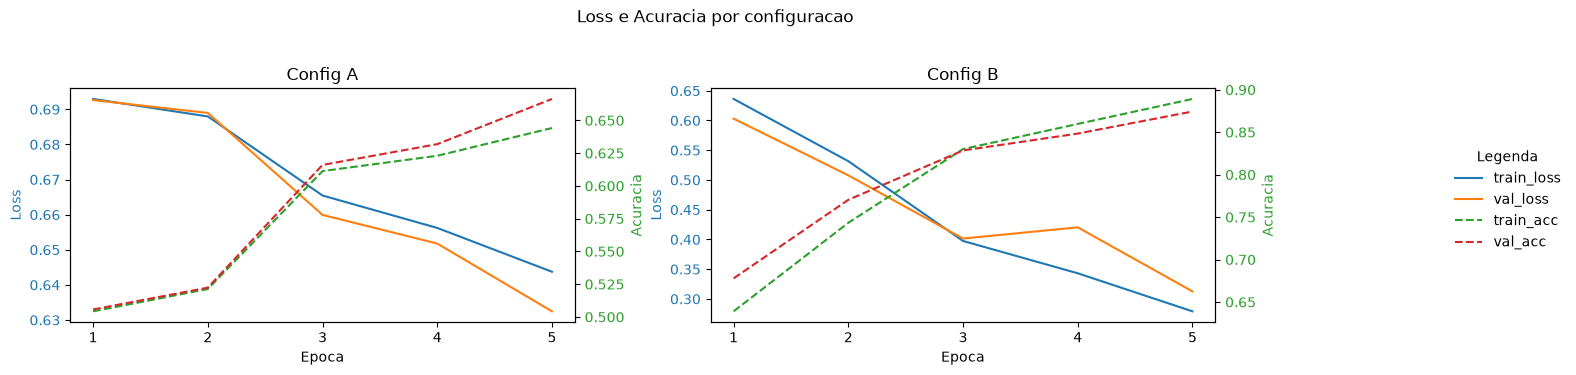

In [ ]:
rows = []
for cfg_name, run in lstm_experiment_runs.items():
    tm = run["test_metrics"]
    rows.append({
        "config": cfg_name,
        "loss": tm["loss"],
        "accuracy": tm["acc"],
        "precision": tm["precision"],
        "recall": tm["recall"],
        "f1": tm["f1"],
    })
lstm_metrics_df = pd.DataFrame(rows)

print("Metricas (LSTM):")
display(lstm_metrics_df.style.hide(axis="index"))

print("Matrizes de confusão (uma por config):")
for cfg_name, run in lstm_experiment_runs.items():
    print(f"\n{cfg_name}")
    display(run["confusion_matrix_df"])

base_examples_df = df_test_model[["text"]].reset_index(drop=True).copy()
base_examples_df["true_label"] = y_test

first_run = next(iter(lstm_experiment_runs.values()))
model = first_run["model"]
model.eval()

all_preds = []
with torch.no_grad():
    for xb, _ in lstm_test_loader:
        xb = xb.to(device, non_blocking=True)
        logits = model(xb)
        batch_preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(batch_preds.tolist())

pred_df = base_examples_df.copy()
pred_df["pred_label"] = all_preds
pred_df["is_correct"] = pred_df["true_label"] == pred_df["pred_label"]

correct_df = pred_df[pred_df["is_correct"]].head(1).copy()
wrong_df = pred_df[~pred_df["is_correct"]].head(3).copy()

print("\nExemplo correto:")
if not correct_df.empty:
    correct_example_df = correct_df[["true_label", "pred_label", "text"]].copy()
    display(correct_example_df)
else:
    print("Nao foi possivel encontrar exemplo correto.")

print("\nExemplos incorretos:")
if not wrong_df.empty:
    wrong_examples_df = wrong_df[["true_label", "pred_label", "text"]].copy()
    display(wrong_examples_df)

    print("\nTextos dos 3 incorretos:")
    for i, txt in enumerate(wrong_examples_df["text"].tolist(), start=1):
        print(f"{i}. {txt}\n")
else:
    print("Nao foi possivel encontrar exemplos incorretos.")

cfg_names = list(lstm_experiment_runs.keys())
n_cfg = len(cfg_names)
fig, axes = plt.subplots(1, n_cfg, figsize=(7.2 * n_cfg, 3.6), squeeze=False)
axes = axes[0]

legend_handles = None
legend_labels = None

for i, cfg_name in enumerate(cfg_names):
    run = lstm_experiment_runs[cfg_name]
    history = run["history"]
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    ax1 = axes[i]
    ln1 = ax1.plot(epochs, history["train_loss"], label="train_loss", color="tab:blue")
    ln2 = ax1.plot(epochs, history["val_loss"], label="val_loss", color="tab:orange")
    ax1.set_xlabel("Epoca")
    ax1.set_ylabel("Loss", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")
    ax1.set_xticks(epochs)

    ax2 = ax1.twinx()
    ln3 = ax2.plot(epochs, history["train_acc"], label="train_acc", color="tab:green", linestyle="--")
    ln4 = ax2.plot(epochs, history["val_acc"], label="val_acc", color="tab:red", linestyle="--")
    ax2.set_ylabel("Acuracia", color="tab:green")
    ax2.tick_params(axis="y", labelcolor="tab:green")

    if legend_handles is None:
        legend_handles = ln1 + ln2 + ln3 + ln4
        legend_labels = [l.get_label() for l in legend_handles]

    ax1.set_title(cfg_name)

fig.suptitle("Loss e Acuracia por configuracao", y=1.03)
fig.legend(
    legend_handles,
    legend_labels,
    loc="center left",
    bbox_to_anchor=(1.005, 0.5),
    frameon=False,
    title="Legenda",
)

plt.tight_layout(rect=(0, 0, 0.9, 1))
plt.show()

### Análise & Discussão

Este problema é de classificação binária de sentimento em reviews de filmes do IMDb. A maior parte dos textos fica até 284 palavras no terceiro quartil, com outliers chegando a 2278. A base é grande, com 50 mil exemplos no total entre treino e teste. Como a entrada é texto e a ordem dos tokens carrega informação semântica para prever sentimento, trata-se de uma tarefa de classificação de sequências, e binária por envolver duas classes.

Sobre embeddings e padding, os embeddings transformam tokens em vetores numéricos e permitem representar palavras em um espaço contínuo onde relações semânticas podem ser aprendidas durante o treino. O padding garante tamanho fixo para as sequências dentro dos batches, o que viabiliza processamento vetorizado e treino estável.

A ordem das palavras importa porque sentimento depende da construção da frase, de negações, contraste e contexto local. Textos longos aumentam custo computacional e podem dificultar o aprendizado de dependências distantes quando o modelo é simples, o que justifica comparar arquiteturas com capacidades diferentes.

No experimento foram usadas duas configurações de LSTM com a mesma base de treinamento e pré-processamento, mudando complexidade do modelo. A Config A usa `embedding_dim=64`, `hidden_size=64`, uma camada, sem dropout e sem bidirecionalidade. A Config B usa `embedding_dim=200`, `hidden_size=256`, duas camadas, `dropout=0.3` e bidirecionalidade.

A Config B teve melhor desempenho em todas as métricas, o que era esperado pela maior capacidade de representação. Isso também apareceu no tempo de treino, cerca de 2 minutos na Config A contra 6 minutos na Config B. Não apareceram sinais fortes de overfitting. A Config A mostrou underfitting, com capacidade limitada para separar padrões mais difíceis. O ganho mais forte entre época 2 e 3 também apareceu de forma consistente nas curvas.

A escolha de `max_len_cap=300` foi intencional e faz sentido neste conjunto, como o terceiro quartil ficou em 284 palavras, esse limite cobre bem a maior parte dos exemplos e mantém o custo computacional sob controle. Ainda assim, textos acima desse valor são truncados, então uma parte dos casos muito longos pode perder contexto no final, o que pode ser problemático para reviews que a opinião parece mudar no final do texto.

A LSTM é mais adequada que RNN simples para textos longos porque seus portões controlam melhor o fluxo de informação ao longo da sequência e reduzem o problema de desaparecimento de gradiente, que é o gargalo clássico das RNNs em dependências longas.

Avaliar só acurácia não basta. Mesmo com base balanceada, precisão, recall, F1 e matriz de confusão mostram melhor o comportamento do modelo por classe e ajudam a entender se ele está errando de forma sistemática. No contexto de produto, isso importa porque o custo de erro pode variar: errar uma review muito negativa como positiva pode ser pior do que o contrário em alguns cenários de recomendação.

Nos erros observados, o caso 1 foi: previu 0 e era 1. Os casos 2 e 3 foram: previu 1 e era 0. Nos casos 1 e 2 há mistura de pistas no texto, com termos positivos e negativos aparecendo juntos. No caso 3, o conteúdo parece majoritariamente positivo e mesmo assim o modelo previu negativo, o que mostra que ainda existem erros reais de interpretação mesmo com desempenho geral bom.

O principal trade-off ficou claro: a Config B entrega melhor qualidade, mas cobra mais custo computacional.